# TPWRS Relevance to the 2025 Research Agenda: Evolution 2023-2026

Every TPWRS abstract in the benchmark runs is scored against all 48 RA2025 research questions by
several LLMs. This notebook reduces those scores to one number per abstract-question pair — the mean
across models — classifies that mean as **Low**, **Moderate** or **High** relevance, and tracks how
the mix moves across publication years.

Design choices:

- **RA questions only.** The PRP (programme-affinity) stage is not analysed here; programme-level
  views are built by grouping the RA questions instead.
- **Mean across models, `mistral-small-2603` excluded.** Its 2025 run is incomplete and its score
  distribution is the least discriminating of the panel, so it is dropped from the ensemble.
- **Levels follow `data/prompts/affinity_scoring_scale.yaml`:** Low `<= 40`, Moderate `40-80`,
  High `> 80`. ("Moderate" is the scale's name for the middle band.)
- **Programmes come from `data/processed/ra_grouping_ra2025.csv`** (`Grouping` x `RA2025`). An
  abstract's level for a programme is the highest score it reaches on any question in that
  programme's group, so levels are assigned per programme and are not mutually exclusive.
- **Shares, not counts.** Each year contains a different number of papers, so every trend is
  expressed as a percentage of that year's papers.

## 1. Configuration

New benchmark years are picked up automatically as long as their folder matches
`RESULT_FOLDER_PATTERN`. Plots use matplotlib defaults throughout — no custom style sheet, colour
palette or `rcParams` overrides.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
BENCHMARK_ROOT = REPO_ROOT / "data" / "results" / "affinity_benchmark"
GROUPING_PATH = REPO_ROOT / "data" / "processed" / "ra_grouping_ra2025.csv"
RESULT_FOLDER_PATTERN = "tpwrs_*"
EXCLUDED_MODEL_SLUGS = {"mistral-small-2603"}

LOW_MAX = 40
MODERATE_MAX = 80
LEVEL_ORDER = ["Low", "Moderate", "High"]
LEVEL_BINS = [0, LOW_MAX, MODERATE_MAX, np.inf]

ANALYSIS_OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "16_tpwrs_affinity_analysis"
FIGURE_DIR = ANALYSIS_OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the per-model RA scores

One `ra_affinities.csv` per model per year folder. The publication year is taken from the folder
name (`tpwrs_2024_tpwrs_2024` -> `2024`).

In [2]:
result_folders = sorted(folder for folder in BENCHMARK_ROOT.glob(RESULT_FOLDER_PATTERN) if folder.is_dir())

frames = []
for folder in result_folders:
    for score_path in sorted(folder.glob("*/ra_affinities.csv")):
        if score_path.parent.name in EXCLUDED_MODEL_SLUGS:
            continue
        frame = pd.read_csv(score_path, usecols=["Abstract_Index", "RA2025_ID", "RA_Question", "LLM_Affinity"])
        frame["Year"] = int(re.search(r"(\d{4})", folder.name).group(1))
        frame["Model_Slug"] = score_path.parent.name
        frames.append(frame)

ra_model_scores = pd.concat(frames, ignore_index=True)
ra_model_scores["LLM_Affinity"] = pd.to_numeric(ra_model_scores["LLM_Affinity"], errors="coerce")

YEARS = sorted(ra_model_scores["Year"].unique())
MODEL_SLUGS = sorted(ra_model_scores["Model_Slug"].unique())

print(f"{len(ra_model_scores):,} model-score rows")
print(f"years: {YEARS}")
print(f"models in the ensemble: {MODEL_SLUGS}")
ra_model_scores.head()

1,441,200 model-score rows
years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
models in the ensemble: ['claude-haiku-4.5', 'deepseek-v4-flash-cloud', 'gemini-3.1-flash-lite', 'gemma4-31b-cloud', 'gpt-5.4-mini']


,Abstract_Index,RA2025_ID,RA_Question,LLM_Affinity,Year,Model_Slug
0,10.1109/TPWRS.2014.2316271,41,what additional probabilistic planning methods...,25.0,2015,claude-haiku-4.5
1,10.1109/TPWRS.2014.2316271,10,what methods and tools should be used in plann...,15.0,2015,claude-haiku-4.5
2,10.1109/TPWRS.2014.2316271,43,what changes can be incorporated into the tran...,20.0,2015,claude-haiku-4.5
3,10.1109/TPWRS.2014.2316271,9,what analytical tools and models should be pro...,35.0,2015,claude-haiku-4.5
4,10.1109/TPWRS.2014.2316271,42,what additional planning models and methods ar...,22.0,2015,claude-haiku-4.5


## 3. Coverage and model spread

Two things worth knowing before averaging: whether every model scored every year completely, and how
far apart the models' score levels are. The panel is deliberately heterogeneous, so the ensemble mean
sits between a conservative model (`gpt-5.4-mini`, `deepseek-v4-flash-cloud`) and a generous one
(`gemini-3.1-flash-lite`); a plain mean is the agreed reduction.

`Mean_Score` per year is also the cheapest check that any trend found later is not one model drifting:
the models are identical across years, so a rise should appear in every row, not just one.

In [3]:
coverage = (
    ra_model_scores.groupby(["Model_Slug", "Year"])
    .agg(
        Rows=("LLM_Affinity", "size"),
        Unscored=("LLM_Affinity", lambda scores: scores.isna().sum()),
        Mean_Score=("LLM_Affinity", "mean"),
    )
    .round(1)
    .unstack("Year")
)
display(coverage)

print("abstracts per year:")
print(ra_model_scores.groupby("Year")["Abstract_Index"].nunique().to_string())

Rows                                            \
Year                      2015   2016   2017   2018   2019   2020   2021   
Model_Slug                                                                 
claude-haiku-4.5         17184  25488  23904  33744  24528  23184  26832   
deepseek-v4-flash-cloud  17184  25488  23904  33744  24528  23184  26832   
gemini-3.1-flash-lite    17184  25488  23904  33744  24528  23184  26832   
gemma4-31b-cloud         17184  25488  23904  33744  24528  23184  26832   
gpt-5.4-mini             17184  25488  23904  33744  24528  23184  26832   

                                              ... Mean_Score              \
Year                      2022   2023   2024  ...       2017  2018  2019   
Model_Slug                                    ...                          
claude-haiku-4.5         21648  23952  28896  ...       19.1  20.6  20.7   
deepseek-v4-flash-cloud  21648  23952  28896  ...       10.7  11.4  11.3   
gemini-3.1-flash-lite    21648  23952  28896  ...       27.2  28.1  28.4   
gemma4-31b-cloud         21648  23952  28896  ...       15.8  16.9  17.1   
gpt-5.4-mini             21648  23952  28896  ...       10.9  11.6  11.7   

                                                                   
Year                     2020  2021  2022  2023  2024  2025  2026  
Model_Slug                                                         
claude-haiku-4.5         20.0  21.2  21.9  22.2  22.7  23.4  25.5  
deepseek-v4-flash-cloud  11.2  11.4  11.9  12.5  12.4  12.4  13.3  
gemini-3.1-flash-lite    28.0  29.2  29.2  29.7  30.6  31.1  32.3  
gemma4-31b-cloud         17.5  17.3  17.9  17.8  18.3  18.8  19.5  
gpt-5.4-mini             11.9  12.6  13.0  13.2  13.6  14.1  14.4  

[5 rows x 36 columns]

abstracts per year:
Year
2015    358
2016    531
2017    498
2018    703
2019    511
2020    483
2021    559
2022    451
2023    499
2024    602
2025    452
2026    358


## 4. Ensemble mean and relevance level

One row per (year, abstract, question): the mean affinity across the models that returned a score,
then the Low / Moderate / High band.

In [4]:
ra_pairs = (
    ra_model_scores.dropna(subset=["LLM_Affinity"])
    .groupby(["Year", "Abstract_Index", "RA2025_ID"], as_index=False)
    .agg(Affinity=("LLM_Affinity", "mean"), Models_Scored=("Model_Slug", "nunique"))
)
ra_pairs["Level"] = pd.cut(ra_pairs["Affinity"], bins=LEVEL_BINS, labels=LEVEL_ORDER, right=False)

print(f"{len(ra_pairs):,} abstract-question pairs")
print("\nmodels contributing to each pair:")
print(ra_pairs["Models_Scored"].value_counts().sort_index().to_string())
print("\noverall level mix (%):")
print(ra_pairs["Level"].value_counts(normalize=True).mul(100).round(2).to_string())

288,240 abstract-question pairs

models contributing to each pair:
Models_Scored
5    288240

overall level mix (%):
Level
Low         90.21
Moderate     9.22
High         0.56


## 5. Attach the programme grouping

`ra_grouping_ra2025.csv` maps each RA2025 question to its programme. The programme order in the file
follows the question numbering, so it is kept as the categorical order used by every table and chart.

In [5]:
ra_grouping = (
    pd.read_csv(GROUPING_PATH, usecols=["Grouping", "RA2025"])
    .rename(columns={"Grouping": "Programme", "RA2025": "RA2025_ID"})
)
PROGRAMME_ORDER = list(dict.fromkeys(ra_grouping["Programme"]))
question_text = ra_model_scores[["RA2025_ID", "RA_Question"]].drop_duplicates().set_index("RA2025_ID")["RA_Question"]

ra_pairs = ra_pairs.merge(ra_grouping, on="RA2025_ID", how="left")
ra_pairs["Programme"] = pd.Categorical(ra_pairs["Programme"], categories=PROGRAMME_ORDER, ordered=True)
abstracts_per_year = ra_pairs.groupby("Year")["Abstract_Index"].nunique()

print(f"questions without a programme: {ra_pairs['Programme'].isna().sum()}")
print(ra_grouping.groupby("Programme", sort=False).size().rename("questions").to_string())

questions without a programme: 0
Programme
IBR                 6
Stability           5
DER                 7
CROF                9
System Services     9
Planning           12


## 6. Per-question summary

For each question and year: how many of that year's papers land in each level, and the same as a
percentage of the year's papers. `Share_Moderate_Or_High` is the single-number "how much of this
year's output speaks to this question" measure used by the charts below.

In [6]:
question_year = (
    ra_pairs.pivot_table(index=["Programme", "RA2025_ID", "Year"], columns="Level",
                         values="Abstract_Index", aggfunc="count", fill_value=0, observed=True)
    .reindex(columns=LEVEL_ORDER, fill_value=0)
    .rename(columns=lambda level: f"N_{level}")
    .reset_index()
)
question_year["N_Abstracts"] = question_year["Year"].map(abstracts_per_year)
for level in LEVEL_ORDER:
    question_year[f"Share_{level}"] = question_year[f"N_{level}"] / question_year["N_Abstracts"] * 100
question_year["Share_Moderate_Or_High"] = question_year["Share_Moderate"] + question_year["Share_High"]

mean_affinity = ra_pairs.groupby(["RA2025_ID", "Year"], observed=True)["Affinity"].mean().round(2)
question_year = question_year.merge(mean_affinity.rename("Mean_Affinity"), on=["RA2025_ID", "Year"])
question_year["RA_Question"] = question_year["RA2025_ID"].map(question_text)
question_year = question_year.sort_values(["RA2025_ID", "Year"]).reset_index(drop=True)

question_year.head(8)

,Programme,RA2025_ID,Year,N_Low,N_Moderate,N_High,N_Abstracts,Share_Low,Share_Moderate,Share_High,Share_Moderate_Or_High,Mean_Affinity,RA_Question
0,IBR,1,2015,336,22,0,358,93.854749,6.145251,0.000000,6.145251,16.31,what is the future of active power balance as ...
1,IBR,1,2016,483,45,3,531,90.960452,8.474576,0.564972,9.039548,18.48,what is the future of active power balance as ...
2,IBR,1,2017,445,53,0,498,89.357430,10.642570,0.000000,10.642570,18.43,what is the future of active power balance as ...
3,IBR,1,2018,631,66,6,703,89.758179,9.388336,0.853485,10.241821,18.77,what is the future of active power balance as ...
4,IBR,1,2019,453,54,4,511,88.649706,10.567515,0.782779,11.350294,19.09,what is the future of active power balance as ...
5,IBR,1,2020,426,52,5,483,88.198758,10.766046,1.035197,11.801242,19.26,what is the future of active power balance as ...
6,IBR,1,2021,491,66,2,559,87.835420,11.806798,0.357782,12.164580,19.52,what is the future of active power balance as ...
7,IBR,1,2022,390,57,4,451,86.474501,12.638581,0.886918,13.525499,20.08,what is the future of active power balance as ...


## 7. Per-programme relevance

A programme is a group of RA questions, so an abstract's relevance to a programme is the **highest
score it reaches on any question in that group**, banded into Low / Moderate / High on the same
thresholds. `Best_RA2025_ID` records which question drove the level.

These levels are **not exclusive**: every abstract carries one level for each of the six programmes,
so the same paper can be High for Stability and Low for DER. Shares therefore sum to 100% within a
programme-year, never across programmes — the last cell below shows how many programmes a typical
paper reaches at Moderate or above.

In [7]:
programme_paper_best = (
    ra_pairs.loc[
        ra_pairs.groupby(["Year", "Abstract_Index", "Programme"], observed=True)["Affinity"].idxmax(),
        ["Year", "Abstract_Index", "Programme", "RA2025_ID", "Affinity"],
    ]
    .rename(columns={"RA2025_ID": "Best_RA2025_ID", "Affinity": "Best_Affinity"})
    .reset_index(drop=True)
)
programme_paper_best["Level"] = pd.cut(programme_paper_best["Best_Affinity"], bins=LEVEL_BINS, labels=LEVEL_ORDER, right=False)

programme_year = (
    programme_paper_best.pivot_table(index=["Programme", "Year"], columns="Level",
                                     values="Abstract_Index", aggfunc="count", fill_value=0, observed=True)
    .reindex(columns=LEVEL_ORDER, fill_value=0)
    .rename(columns=lambda level: f"N_{level}")
    .reset_index()
)
programme_year["N_Abstracts"] = programme_year["Year"].map(abstracts_per_year)
for level in LEVEL_ORDER:
    programme_year[f"Share_{level}"] = programme_year[f"N_{level}"] / programme_year["N_Abstracts"] * 100
programme_year["Share_Moderate_Or_High"] = programme_year["Share_Moderate"] + programme_year["Share_High"]

programme_year.round(1)

Level,Programme,Year,N_Low,N_Moderate,N_High,N_Abstracts,Share_Low,Share_Moderate,Share_High,Share_Moderate_Or_High
0,IBR,2015,298,57,3,358,83.2,15.9,0.8,16.8
1,IBR,2016,430,98,3,531,81.0,18.5,0.6,19.0
2,IBR,2017,400,94,4,498,80.3,18.9,0.8,19.7
3,IBR,2018,553,138,12,703,78.7,19.6,1.7,21.3
4,IBR,2019,397,106,8,511,77.7,20.7,1.6,22.3
...,...,...,...,...,...,...,...,...,...,...
67,Planning,2022,299,132,20,451,66.3,29.3,4.4,33.7
68,Planning,2023,341,132,26,499,68.3,26.5,5.2,31.7
69,Planning,2024,394,186,22,602,65.4,30.9,3.7,34.6
70,Planning,2025,276,159,17,452,61.1,35.2,3.8,38.9


In [8]:
programmes_reached = (
    programme_paper_best.assign(Above_Low=programme_paper_best["Level"] != "Low")
    .groupby(["Year", "Abstract_Index"], observed=True)["Above_Low"]
    .sum()
    .rename("Programmes_Above_Low")
)

print("How many of the 6 programmes each paper reaches at Moderate or High (% of papers):")
display(
    programmes_reached.groupby("Year")
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .unstack("Programmes_Above_Low")
    .fillna(0)
)

How many of the 6 programmes each paper reaches at Moderate or High (% of papers):


Programmes_Above_Low,0,1,2,3,4,5,6
Year,,,,,,,
2015,18.2,23.5,22.1,21.8,11.2,3.1,0.3
2016,18.6,17.1,27.7,18.5,13.4,4.5,0.2
2017,21.3,19.3,25.9,18.7,10.6,3.8,0.4
2018,17.1,19.1,23.9,22.3,11.8,4.4,1.4
2019,17.6,16.2,24.3,24.1,11.7,5.3,0.8
2020,19.3,18.0,24.8,19.3,12.8,5.4,0.4
2021,16.6,14.8,24.3,23.4,13.4,6.4,0.9
2022,13.7,16.4,24.6,22.2,15.5,6.9,0.7
2023,16.0,13.6,23.6,22.8,15.8,7.2,0.8


## 8. Headline: the relevance mix over time

Left panel: every abstract-question pair. Because each paper is scored against all 48 questions and
addresses only a few, ~88% of pairs are necessarily Low — this panel shows the drift of that baseline.

Right panel: each paper's best-matching question anywhere in the agenda, which is the readable version
of the same trend.

In [9]:
paper_best = ra_pairs.groupby(["Year", "Abstract_Index"], as_index=False).agg(Best_Affinity=("Affinity", "max"))
paper_best["Best_Level"] = pd.cut(paper_best["Best_Affinity"], bins=LEVEL_BINS, labels=LEVEL_ORDER, right=False)
paper_level_counts = (
    paper_best.pivot_table(index="Year", columns="Best_Level", values="Abstract_Index",
                           aggfunc="count", fill_value=0, observed=True)
    .reindex(columns=LEVEL_ORDER, fill_value=0)
)
paper_best

,Year,Abstract_Index,Best_Affinity,Best_Level
0,2015,10.1109/TPWRS.2014.2316271,61.4,Moderate
1,2015,10.1109/TPWRS.2014.2318293,79.4,Moderate
2,2015,10.1109/TPWRS.2014.2319310,75.4,Moderate
3,2015,10.1109/TPWRS.2014.2319315,35.6,Low
4,2015,10.1109/TPWRS.2014.2319588,39.4,Low
...,...,...,...,...
6000,2026,10.1109/TPWRS.2026.3706692,73.6,Moderate
6001,2026,10.1109/TPWRS.2026.3707026,76.6,Moderate
6002,2026,10.1109/TPWRS.2026.3707037,68.8,Moderate
6003,2026,10.1109/TPWRS.2026.3707100,80.2,High


In [10]:
pair_level_counts = (
    ra_pairs.pivot_table(index="Year", columns="Level", values="Abstract_Index",
                         aggfunc="count", fill_value=0, observed=True)
    .reindex(columns=LEVEL_ORDER, fill_value=0)
)
pair_level_share = pair_level_counts.div(pair_level_counts.sum(axis=1), axis=0).mul(100)

paper_best = ra_pairs.groupby(["Year", "Abstract_Index"], as_index=False).agg(Best_Affinity=("Affinity", "max"))
paper_best["Best_Level"] = pd.cut(paper_best["Best_Affinity"], bins=LEVEL_BINS, labels=LEVEL_ORDER, right=False)
paper_level_counts = (
    paper_best.pivot_table(index="Year", columns="Best_Level", values="Abstract_Index",
                           aggfunc="count", fill_value=0, observed=True)
    .reindex(columns=LEVEL_ORDER, fill_value=0)
)
paper_level_share = paper_level_counts.div(paper_level_counts.sum(axis=1), axis=0).mul(100)

overall_year = pd.concat(
    {"Pair_Share": pair_level_share.round(2), "Paper_Share": paper_level_share.round(2)}, axis=1
)
overall_year

Pair_Share                Paper_Share                
Level        Low Moderate  High         Low Moderate   High
Year                                                       
2015       92.07     7.57  0.36       18.16    67.32  14.53
2016       91.59     8.05  0.36       18.64    67.04  14.31
2017       91.96     7.68  0.35       21.29    64.46  14.26
2018       90.85     8.69  0.46       17.07    65.01  17.92
2019       90.81     8.72  0.47       17.61    65.36  17.03
2020       91.00     8.50  0.50       19.25    61.08  19.67
2021       90.08     9.41  0.52       16.64    65.12  18.25
2022       89.52     9.89  0.60       13.75    64.52  21.73
2023       89.25    10.00  0.75       16.03    58.32  25.65
2024       89.14    10.17  0.69        8.80    67.28  23.92
2025       88.47    10.83  0.70       13.50    63.27  23.23
2026       87.14    11.68  1.18       13.69    52.79  33.52

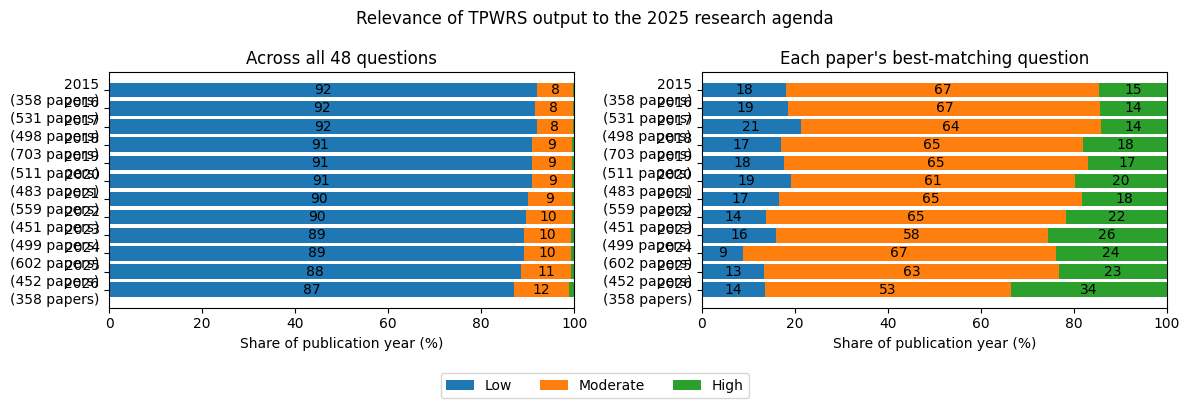

In [11]:
year_labels = [f"{year}\n({abstracts_per_year[year]} papers)" for year in YEARS]
positions = np.arange(len(YEARS))
panels = [
    (pair_level_share, "Across all 48 questions"),
    (paper_level_share, "Each paper's best-matching question"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (table, panel_title) in zip(axes, panels):
    left = np.zeros(len(table))
    for level in LEVEL_ORDER:
        values = table[level].to_numpy()
        bars = ax.barh(positions, values, left=left, label=level)
        ax.bar_label(bars, labels=[f"{value:.0f}" if value >= 7 else "" for value in values],
                     label_type="center")
        left = left + values
    ax.set_yticks(positions, year_labels)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("Share of publication year (%)")
    ax.set_title(panel_title)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=3)
fig.suptitle("Relevance of TPWRS output to the 2025 research agenda")
fig.tight_layout(rect=(0, 0.09, 1, 1))
fig.savefig(FIGURE_DIR / "01_overall_level_mix_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Programme-level evolution

One panel per programme keeps the three levels legible; the line chart then isolates the High band so
the programmes can be compared directly.

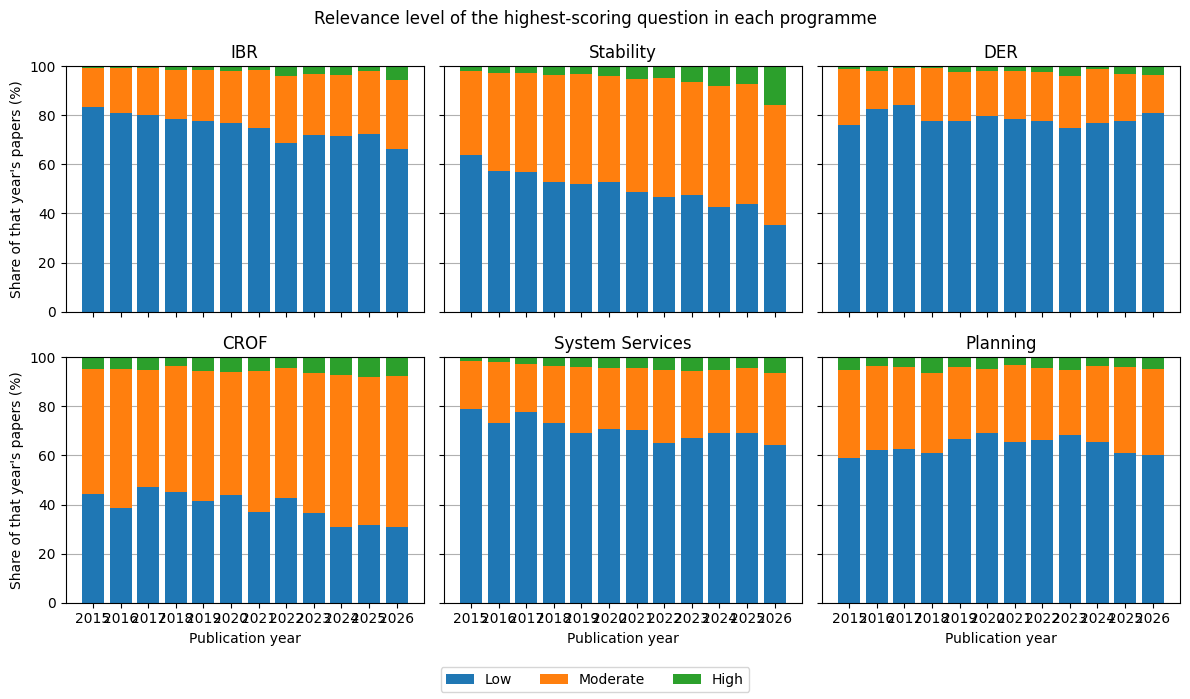

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
for ax, programme in zip(axes.ravel(), PROGRAMME_ORDER):
    block = programme_year[programme_year["Programme"] == programme].set_index("Year")
    bottom = np.zeros(len(block))
    for level in LEVEL_ORDER:
        values = block[f"Share_{level}"].to_numpy()
        ax.bar(block.index.astype(str), values, bottom=bottom, label=level)
        bottom = bottom + values
    ax.set_title(programme)
    ax.set_ylim(0, 100)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
for ax in axes[:, 0]:
    ax.set_ylabel("Share of that year's papers (%)")
for ax in axes[-1, :]:
    ax.set_xlabel("Publication year")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=3)
fig.suptitle("Relevance level of the highest-scoring question in each programme")
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(FIGURE_DIR / "02_programme_level_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
programme_year

Level,Programme,Year,N_Low,N_Moderate,N_High,N_Abstracts,Share_Low,Share_Moderate,Share_High,Share_Moderate_Or_High
0,IBR,2015,298,57,3,358,83.240223,15.921788,0.837989,16.759777
1,IBR,2016,430,98,3,531,80.979284,18.455744,0.564972,19.020716
2,IBR,2017,400,94,4,498,80.321285,18.875502,0.803213,19.678715
3,IBR,2018,553,138,12,703,78.662873,19.630156,1.706970,21.337127
4,IBR,2019,397,106,8,511,77.690802,20.743640,1.565558,22.309198
...,...,...,...,...,...,...,...,...,...,...
67,Planning,2022,299,132,20,451,66.297118,29.268293,4.434590,33.702882
68,Planning,2023,341,132,26,499,68.336673,26.452906,5.210421,31.663327
69,Planning,2024,394,186,22,602,65.448505,30.897010,3.654485,34.551495
70,Planning,2025,276,159,17,452,61.061947,35.176991,3.761062,38.938053


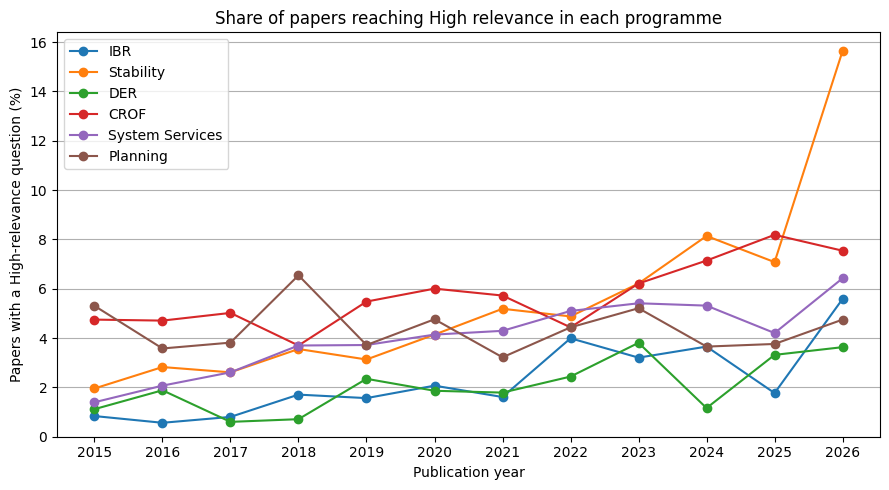

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
for programme in PROGRAMME_ORDER:
    block = programme_year[programme_year["Programme"] == programme].sort_values("Year")
    ax.plot(block["Year"], block["Share_High"], marker="o", label=programme)

ax.set_xticks(YEARS)
ax.set_ylim(0, None)
ax.set_xlabel("Publication year")
ax.set_ylabel("Papers with a High-relevance question (%)")
ax.set_title("Share of papers reaching High relevance in each programme")
ax.legend()
ax.grid(axis="y")
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_programme_high_share_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Per-question evolution

The heatmap is the full 48-question picture: each cell is the share of that year's papers scoring
Moderate or High on that question, with questions grouped by programme. The bar chart then ranks the
questions by how much that share moved between the first and last year available.

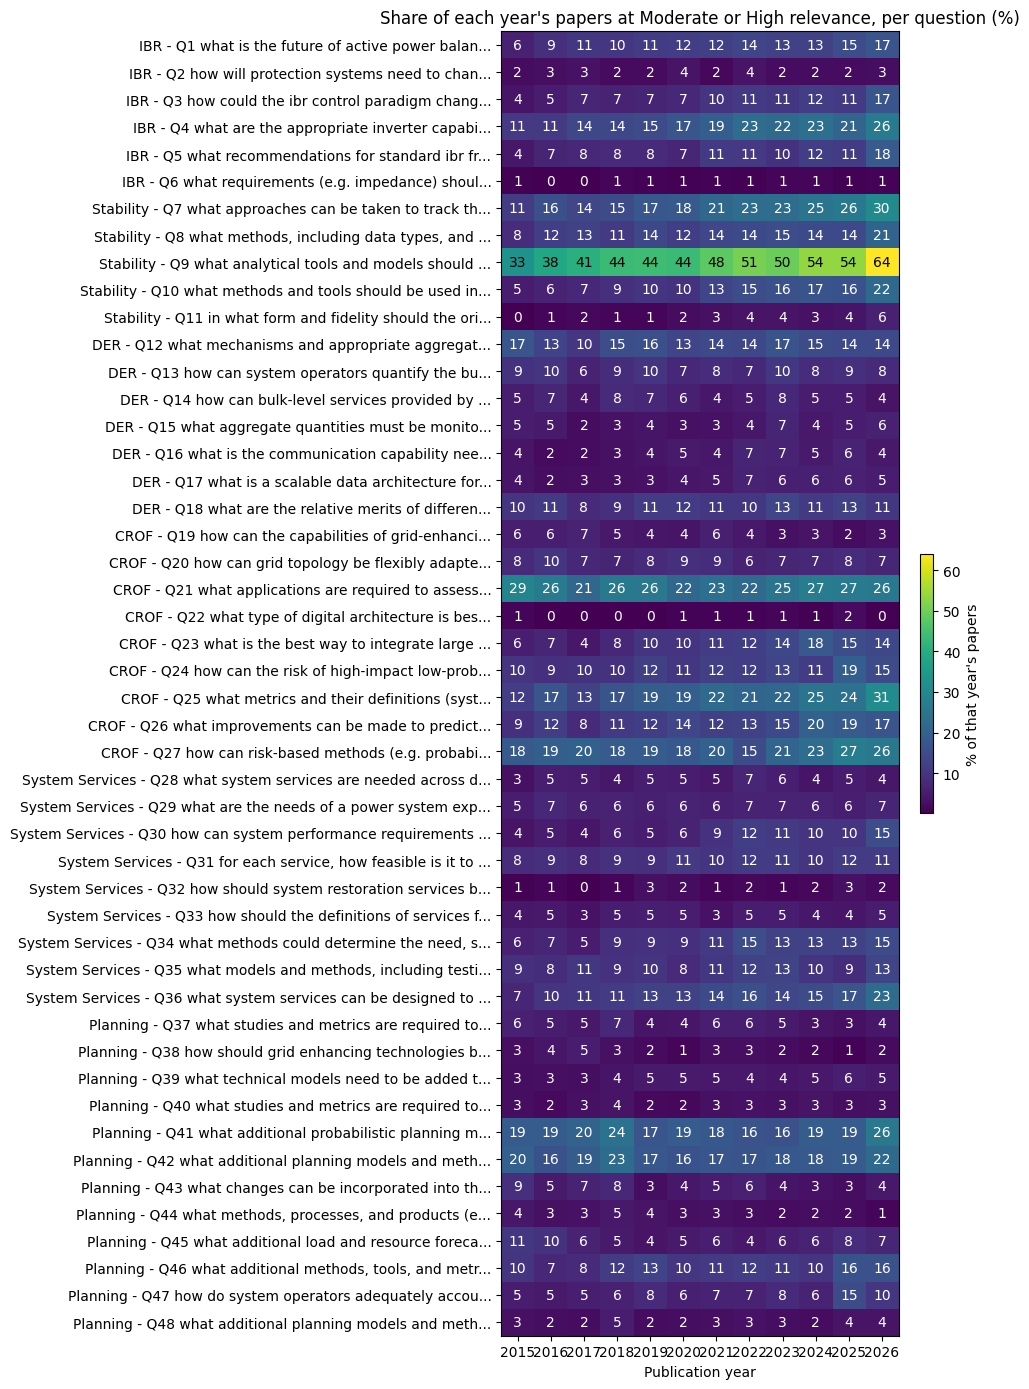

In [15]:
question_heat = (
    question_year.pivot_table(index=["Programme", "RA2025_ID"], columns="Year",
                             values="Share_Moderate_Or_High", observed=True)
    .reindex(PROGRAMME_ORDER, level="Programme")
)
heat_values = question_heat.to_numpy()
heat_labels = [
    f"{programme} - Q{ra_id} {question_text[ra_id][:40]}..." for programme, ra_id in question_heat.index
]

fig, ax = plt.subplots(figsize=(10, 14))
image = ax.imshow(heat_values, aspect="auto")
ax.set_xticks(range(len(question_heat.columns)), [str(year) for year in question_heat.columns])
ax.set_yticks(range(len(question_heat)), heat_labels)

label_threshold = heat_values.max() / 2
for row in range(heat_values.shape[0]):
    for col in range(heat_values.shape[1]):
        ax.text(col, row, f"{heat_values[row, col]:.0f}", ha="center", va="center",
                color="white" if heat_values[row, col] < label_threshold else "black")

ax.set_xlabel("Publication year")
ax.set_title("Share of each year's papers at Moderate or High relevance, per question (%)")
fig.colorbar(image, ax=ax, fraction=0.03, label="% of that year's papers")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_question_year_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

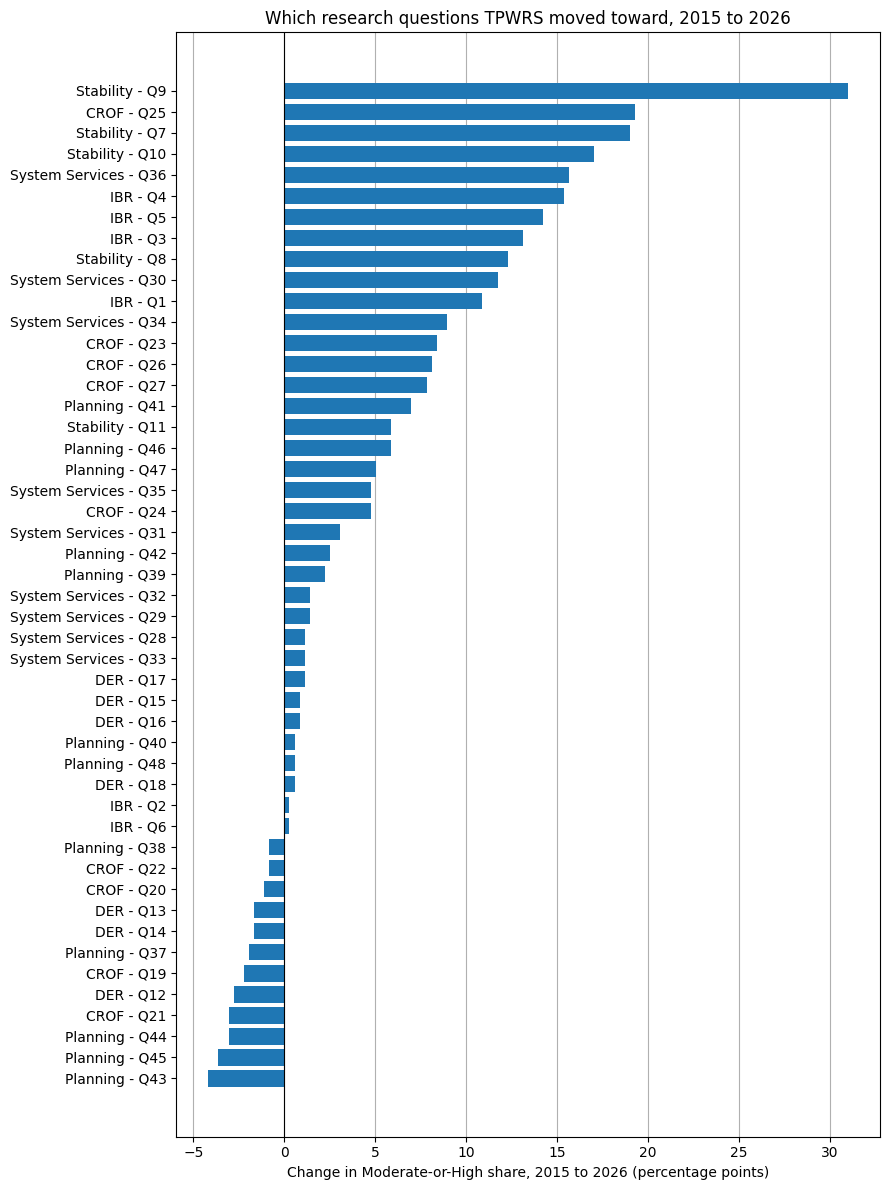

In [16]:
FIRST_YEAR, LAST_YEAR = YEARS[0], YEARS[-1]

question_change = question_heat.reset_index()
question_change["Change_pp"] = question_change[LAST_YEAR] - question_change[FIRST_YEAR]
question_change = question_change.sort_values("Change_pp").reset_index(drop=True)

positions = np.arange(len(question_change))

fig, ax = plt.subplots(figsize=(9, 12))
ax.barh(positions, question_change["Change_pp"])
ax.set_yticks(
    positions,
    [f"{programme} - Q{ra_id}" for programme, ra_id in zip(question_change["Programme"], question_change["RA2025_ID"])],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Change in Moderate-or-High share, {FIRST_YEAR} to {LAST_YEAR} (percentage points)")
ax.set_title(f"Which research questions TPWRS moved toward, {FIRST_YEAR} to {LAST_YEAR}")
ax.grid(axis="x")
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_question_change_first_to_last.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Where the agenda is best and least served

Two shortlists from the latest year: the questions the journal engages with most, and the ones it
barely touches. The `Change_pp` column carries the movement since the first year, so a low-coverage
question that is climbing reads differently from one that is flat.

In [17]:
latest = question_year[question_year["Year"] == LAST_YEAR].set_index("RA2025_ID")
shortlist = pd.DataFrame({
    "Programme": latest["Programme"],
    "Share_Moderate_Or_High": latest["Share_Moderate_Or_High"].round(1),
    "Share_High": latest["Share_High"].round(1),
    "Mean_Affinity": latest["Mean_Affinity"],
    "Change_pp": question_change.set_index("RA2025_ID")["Change_pp"].round(1),
    "RA_Question": latest["RA_Question"].str.slice(0, 90) + "...",
}).sort_values("Share_Moderate_Or_High", ascending=False)

print(f"Best-served questions in {LAST_YEAR}")
display(shortlist.head(10))
print(f"Least-served questions in {LAST_YEAR}")
display(shortlist.tail(10))

Best-served questions in 2026


,Programme,Share_Moderate_Or_High,Share_High,Mean_Affinity,Change_pp,RA_Question
RA2025_ID,,,,,,
9,Stability,64.0,7.0,50.01,31.0,what analytical tools and models should be pro...
25,CROF,31.0,2.5,31.50,19.3,what metrics and their definitions (system str...
7,Stability,30.4,2.5,30.41,19.0,what approaches can be taken to track the dyna...
4,IBR,26.3,4.5,28.25,15.4,what are the appropriate inverter capabilities...
21,CROF,26.0,1.4,30.98,-3.1,what applications are required to assess adequ...
27,CROF,25.7,0.8,28.42,7.8,how can risk-based methods (e.g. probabilistic...
41,Planning,25.7,1.4,28.71,7.0,what additional probabilistic planning methods...
36,System Services,22.6,4.2,28.29,15.6,what system services can be designed to enable...
42,Planning,22.3,0.6,26.85,2.5,what additional planning models and methods ar...


Least-served questions in 2026


,Programme,Share_Moderate_Or_High,Share_High,Mean_Affinity,Change_pp,RA_Question
RA2025_ID,,,,,,
14,DER,3.6,1.1,13.32,-1.7,how can bulk-level services provided by der be...
48,Planning,3.6,0.3,15.18,0.6,what additional planning models and methods ar...
19,CROF,3.4,0.3,14.38,-2.2,how can the capabilities of grid-enhancing tec...
40,Planning,3.1,0.3,14.93,0.6,what studies and metrics are required to evalu...
2,IBR,2.5,0.0,12.08,0.3,how will protection systems need to change to ...
38,Planning,2.0,0.0,12.01,-0.8,how should grid enhancing technologies be incl...
32,System Services,2.0,0.6,12.17,1.4,how should system restoration services be stru...
44,Planning,1.1,0.0,10.99,-3.1,"what methods, processes, and products (e.g. se..."
6,IBR,0.8,0.0,10.50,0.3,what requirements (e.g. impedance) should be p...


## 12. Exports

Pair-level ensemble scores plus every summary table, written next to the figures so a report or
another notebook can reuse them without rerunning the aggregation.

In [18]:
exports = {
    "ra_ensemble_pairs.csv": ra_pairs,
    "overall_year_summary.csv": overall_year.reset_index(),
    "question_year_summary.csv": question_year,
    "question_year_moderate_or_high.csv": question_heat.reset_index(),
    "question_change_first_to_last.csv": question_change,
    "programme_year_summary.csv": programme_year,
    "programme_paper_levels.csv": programme_paper_best,
    "latest_year_question_shortlist.csv": shortlist.reset_index(),
}

for filename, table in exports.items():
    table.to_csv(ANALYSIS_OUTPUT_DIR / filename, index=False)

print(f"Saved {len(exports)} tables to {ANALYSIS_OUTPUT_DIR}")
print(f"Saved {len(list(FIGURE_DIR.glob('*.png')))} figures to {FIGURE_DIR}")

Saved 8 tables to /mnt/c/Users/pgallego/OneDrive - Imperial College London/PhD/Repositories/article-classifier/notebooks/outputs/16_tpwrs_affinity_analysis
Saved 5 figures to /mnt/c/Users/pgallego/OneDrive - Imperial College London/PhD/Repositories/article-classifier/notebooks/outputs/16_tpwrs_affinity_analysis/figures
